In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [24]:
image_path = "images.jpg"
img = np.array(Image.open(image_path).convert("L"))

In [25]:
print("Original image shape:", img.shape)
print("Original image data type:", img.dtype)

Original image shape: (373, 745)
Original image data type: uint8


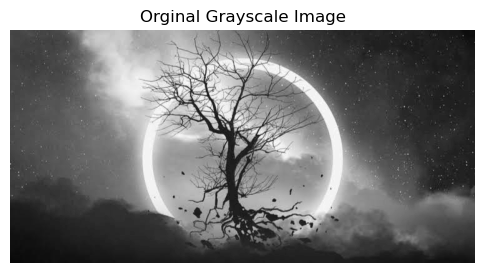

In [26]:
plt.figure(figsize=(6,5))
plt.imshow(img,cmap = "gray")
plt.title("Orginal Grayscale Image")
plt.axis("off")
plt.show()

In [27]:
def downsample(image, factor):
    """Keep only every 'factor' -th pixel in rows and colums."""
    return image[::factor, ::factor]

(-0.5, 744.5, 372.5, -0.5)

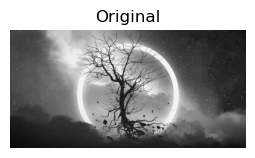

In [28]:
factors = [2, 4, 8]
plt.figure(figsize = (14,4))
plt.subplot(1, len(factors) + 1, 1)
plt.imshow(img, cmap = "gray")
plt.title("Original")
plt.axis("off")

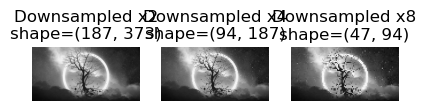

In [29]:
for i, f in enumerate(factors):
    small = downsample(img, f)
    plt.subplot(1, len(factors) + 1, i + 2)
    plt.imshow(small, cmap="gray")
    plt.title(f"Downsampled x{f}\nshape={small.shape}")
    plt.axis("off")

In [30]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [31]:
small_img = downsample(img, 8)
pil_small = Image.fromarray(small_img)
upsampled = pil_small.resize((img.shape[1], img.shape[0]),Image.Resampling.NEAREST)
upsampled = np.array(upsampled)

(-0.5, 744.5, 372.5, -0.5)

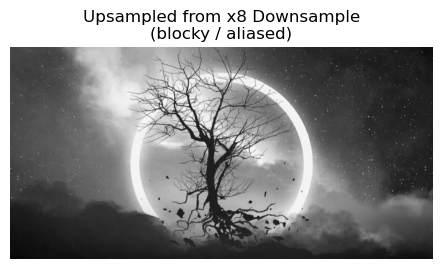

In [32]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(img, cmap="gray")
plt.title("Upsampled from x8 Downsample\n(blocky / aliased)")
plt.axis("off")

In [33]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [35]:
print("\nSampling: reducing resolution loses spatail permanetly.")
print("Upsampling only stretches existing pixels; it cannot recover lost detail.")


Sampling: reducing resolution loses spatail permanetly.
Upsampling only stretches existing pixels; it cannot recover lost detail.


In [51]:
def quantize(image,levels):
    """
    Reduce an 8-bit (0-255) grayscale image to a smaller number of gray levels.
    'levels' is how many distinct gray shades the output should have (e.g. 4, 8, )
    """
    
    step = 256 // levels
    quantized = (image // step) * step
    return quantized.astype(np.uint8)

In [52]:
level_options = [256, 16, 8, 4, 2]
plt.figure(figsize=(16, 4))

<Figure size 1600x400 with 0 Axes>

<Figure size 1600x400 with 0 Axes>

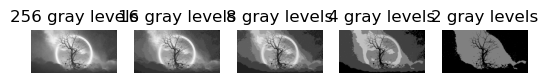

In [53]:
for i, levels in enumerate(level_options):
    q_img = quantize(img, levels)
    plt.subplot(1, len(level_options), i + 1)
    plt.imshow(q_img, cmap="gray", vmin=0, vmax=255)
    plt.title(f"{levels} gray levels")
    plt.axis("off")

In [47]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [54]:
q2 = quantize(img, 2)
q4 = quantize(img, 4)

(-0.5, 744.5, 372.5, -0.5)

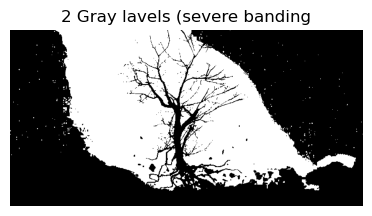

In [55]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(q2, cmap="gray")
plt.title("2 Gray lavels (severe banding")
plt.axis("off")

(-0.5, 744.5, 372.5, -0.5)

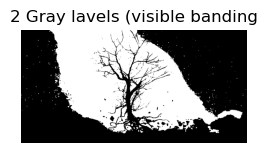

In [56]:
plt.subplot(1,2,2)
plt.imshow(q2, cmap="gray")
plt.title("2 Gray lavels (visible banding")
plt.axis("off")

In [57]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [58]:
print("\nQuantization: reducing gray levels causes visible banding, called 'false contouring'.")
print("Fewer levels = smaller file size but lower visual quality")


Quantization: reducing gray levels causes visible banding, called 'false contouring'.
Fewer levels = smaller file size but lower visual quality
